In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_excel("Customer_churn_Prediction/Telco_customer_churn.xlsx")
print("Dataset Loaded Successfully")
print(df.head())
print(df.columns)

Dataset Loaded Successfully
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

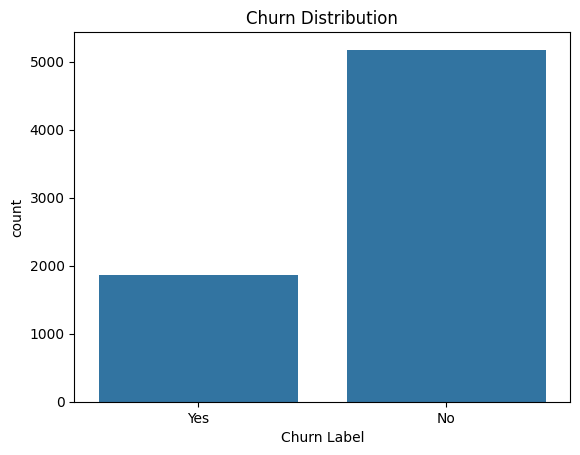

In [3]:
# ------------------------------------------------------------
# 3. BASIC EXPLORATION
# ------------------------------------------------------------
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Churn distribution
sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.show()


In [4]:
# ------------------------------------------------------------
# 4. DATA CLEANING & PREPROCESSING
# ------------------------------------------------------------

# Convert TotalCharges to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

# Drop customerID (not useful for prediction)
df.drop('CustomerID', axis=1, inplace=True)

# Remove leakage columns
leakage_cols = ['Churn Label', 'Churn Score', 'Churn Reason', 'CLTV']
df = df.drop(columns=leakage_cols)

# Encode categorical variables
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Split features and target
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# ------------------------------------------------------------
# 5. MODEL TRAINING
# ------------------------------------------------------------

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)    
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


--- Logistic Regression Performance ---
Accuracy: 0.8048261178140526
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.59      0.63       400

    accuracy                           0.80      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.80      0.80      1409


--- Random Forest Performance ---
Accuracy: 0.7998580553584103
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.70      0.52      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


--- Decision Tree Performance ---
Accuracy: 0.7253371185237757
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1009
           1       0.52      0.48      

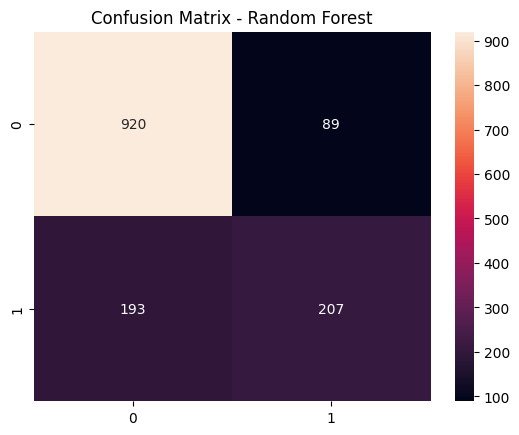

Random Forest ROC-AUC Score: 0.8485133795837462


In [6]:
# ------------------------------------------------------------
# 6. MODEL EVALUATION
# ------------------------------------------------------------

print("\n--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

print("\n--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("\n--- Decision Tree Performance ---")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

print("\n--- Gradient Boosting Performance ---")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

print("\n--- XGBoost Performance ---")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC-AUC Score
rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC Score:", roc_auc_score(y_test, rf_prob))

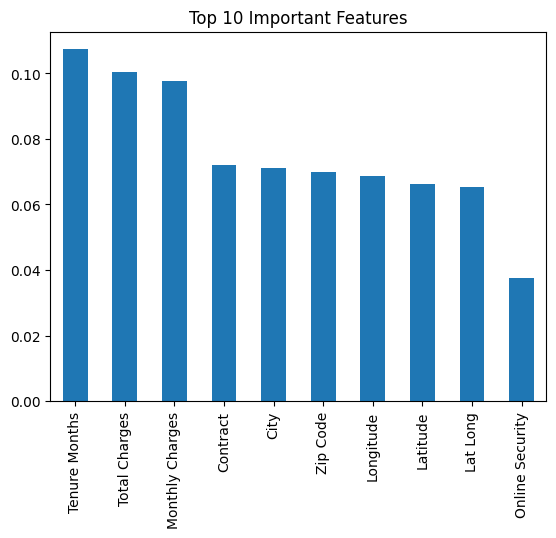

In [7]:
# ------------------------------------------------------------
# 7. FEATURE IMPORTANCE
# ------------------------------------------------------------
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [9]:
# ------------------------------------------------------------
# 9. SAVE ALL MODEL EVALUATIONS TO SINGLE PLACE AND SHOW THE BEST MODEL
# ------------------------------------------------------------

results = []

# Logistic Regression
results.append("=== Logistic Regression ===")
results.append(f"Accuracy: {accuracy_score(y_test, log_pred):.4f}")
results.append(classification_report(y_test, log_pred))

# Random Forest
results.append("\n=== Random Forest ===")
results.append(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
results.append(classification_report(y_test, rf_pred))

# Decision Tree
results.append("\n=== Decision Tree ===")
results.append(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
results.append(classification_report(y_test, dt_pred))

# Gradient Boosting
results.append("\n=== Gradient Boosting ===")
results.append(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
results.append(classification_report(y_test, gb_pred))

# XGBoost
results.append("\n=== XGBoost ===")
results.append(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
results.append(classification_report(y_test, xgb_pred))
# ------------------------------------------------------------
# Identify Best Model
# ------------------------------------------------------------
model_scores = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

best_model = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model]

results.append("\n=== BEST MODEL ===")
results.append(f"Best Model: {best_model}")
results.append(f"Accuracy: {best_score:.4f}")
for line in results:
    print(line)


=== Logistic Regression ===
Accuracy: 0.8048
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.59      0.63       400

    accuracy                           0.80      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.80      0.80      1409


=== Random Forest ===
Accuracy: 0.7999
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.70      0.52      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


=== Decision Tree ===
Accuracy: 0.7253
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1009
           1       0.52      0.48      0.50       400

    accuracy                           0.73      1409
   